In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

torch.set_num_threads(8)

BASE_DIR = r"C:\Users\Rushikesh\OneDrive\CODES\SelfHealingNN"
os.chdir(BASE_DIR)

IMAGE_SIZE = 128
BATCH_SIZE = 16

test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

test_dataset = datasets.ImageFolder(
    root=r"C:\Users\Rushikesh\OneDrive\CODES\SelfHealingNN\medical_data\test",
    transform=test_transforms
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

def add_medical_noise(image_tensor, noise_factor=0.3):
    noise = torch.randn_like(image_tensor) * noise_factor
    return torch.clamp(image_tensor + noise, 0., 1.)

print(f"✅ Test: {len(test_dataset)} images | Classes: {test_dataset.classes}")

✅ Test: 624 images | Classes: ['NORMAL', 'PNEUMONIA']


In [7]:
# ✅ Model classes must match the NEW architectures (with BatchNorm)
class DeepMedicalVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(DeepMedicalVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  32,  3, stride=2, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 64,  3, stride=2, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128,256, 3, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 256 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64,  3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.ConvTranspose2d(64,  32,  3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.ConvTranspose2d(32,  1,   3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, x):
        h      = self.encoder(x).view(-1, 256 * 8 * 8)
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z      = self.reparameterize(mu, logvar)
        h2     = F.relu(self.fc_decode(z)).view(-1, 256, 8, 8)
        return self.decoder(h2), mu, logvar


class MedicalExpertCNN(nn.Module):
    def __init__(self):
        super(MedicalExpertCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,  32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

print("✅ Both model classes defined (with BatchNorm)")

✅ Both model classes defined (with BatchNorm)


In [8]:
healer = DeepMedicalVAE()
expert = MedicalExpertCNN()

healer.load_state_dict(torch.load(
    r"C:\Users\Rushikesh\OneDrive\CODES\SelfHealingNN\models\medical_healer_finetuned.pth",
    weights_only=True
))
expert.load_state_dict(torch.load(
    r"C:\Users\Rushikesh\OneDrive\CODES\SelfHealingNN\models\medical_expert_finetuned.pth",
    weights_only=True
))

healer.eval()
expert.eval()
print("✅ Both models loaded successfully")

✅ Both models loaded successfully


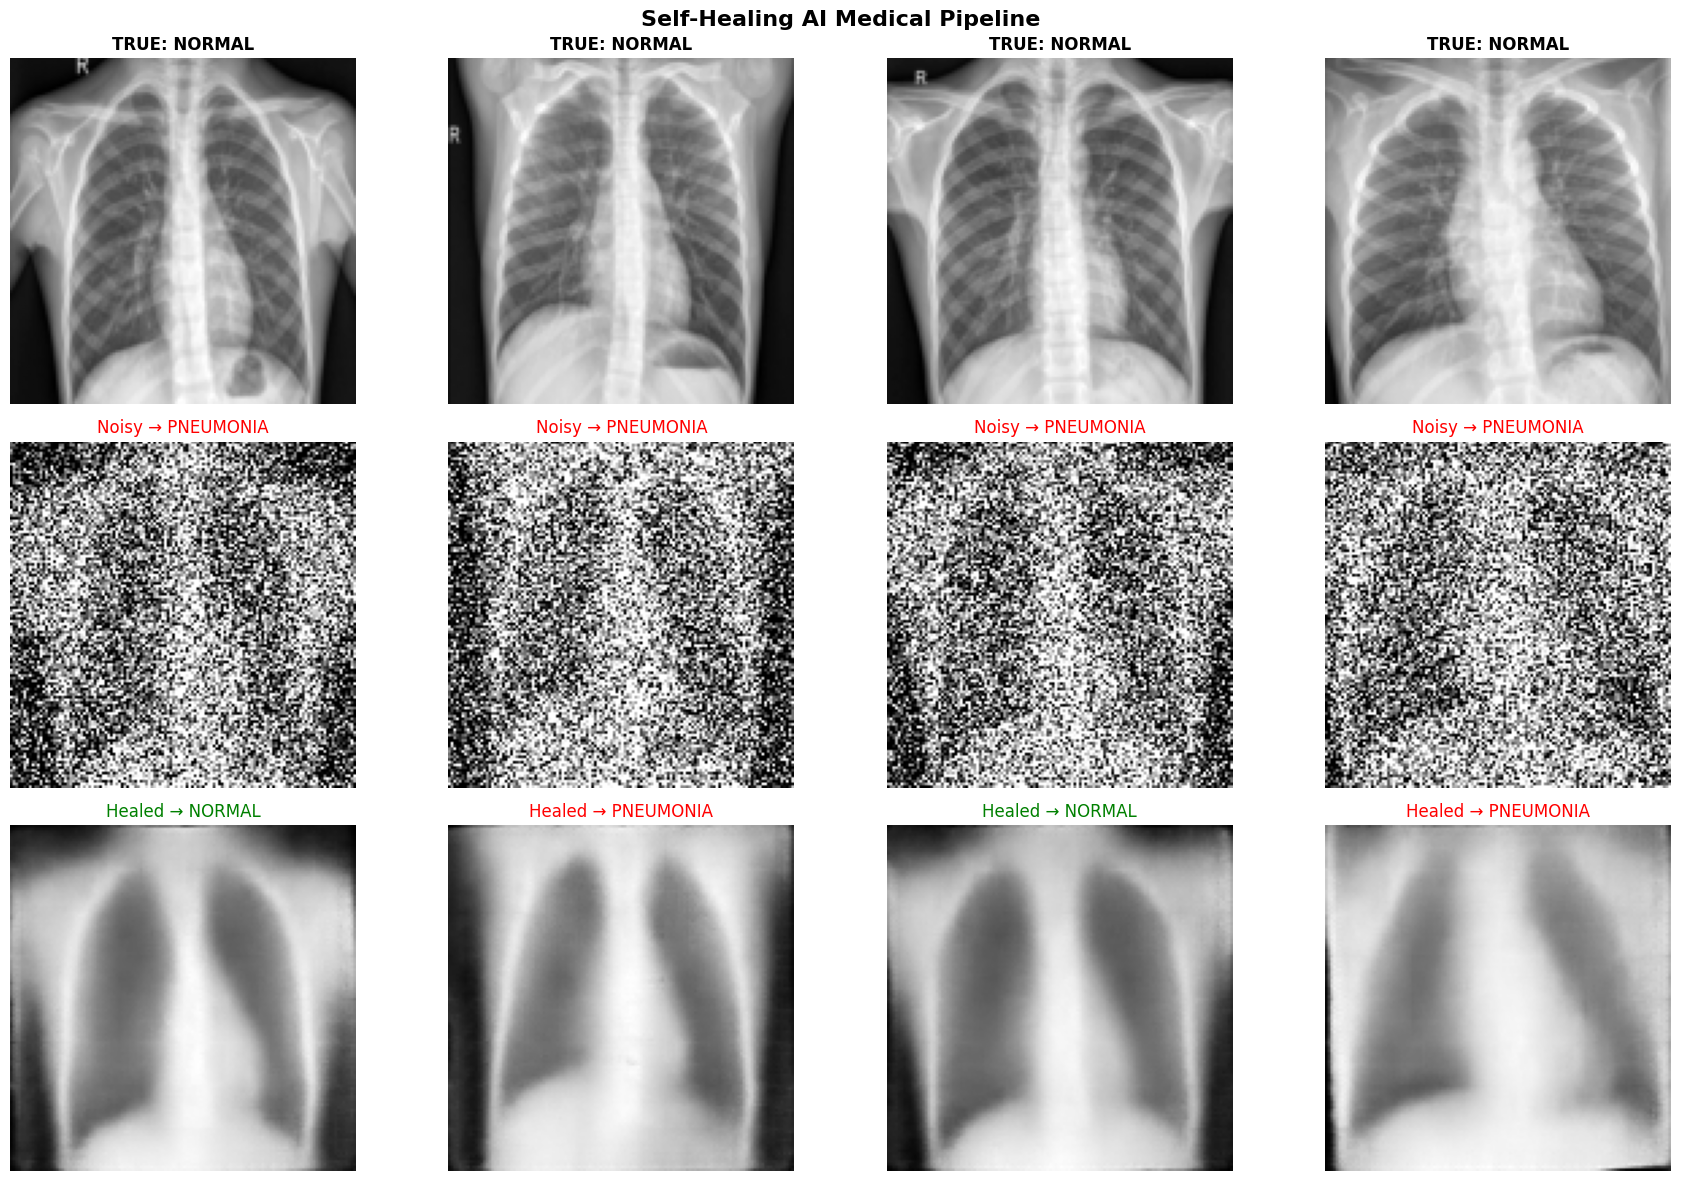

In [9]:
clean_imgs, labels = next(iter(test_loader))
noisy_imgs         = add_medical_noise(clean_imgs, 0.5)

with torch.no_grad():
    healed_imgs, _, _ = healer(noisy_imgs)
    noisy_guesses     = expert(noisy_imgs).argmax(dim=1)
    healed_guesses    = expert(healed_imgs).argmax(dim=1)

classes = test_dataset.classes
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for i in range(4):
    true_label  = classes[labels[i]]
    noisy_pred  = classes[noisy_guesses[i]]
    healed_pred = classes[healed_guesses[i]]

    axes[0, i].imshow(clean_imgs[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f"TRUE: {true_label}", fontweight='bold')

    axes[1, i].imshow(noisy_imgs[i].squeeze(), cmap='gray')
    axes[1, i].set_title(f"Noisy → {noisy_pred}",
                         color='green' if noisy_pred == true_label else 'red')

    axes[2, i].imshow(healed_imgs[i].squeeze().detach(), cmap='gray')
    axes[2, i].set_title(f"Healed → {healed_pred}",
                         color='green' if healed_pred == true_label else 'red')

for ax in axes.flatten():
    ax.axis('off')

plt.suptitle("Self-Healing AI Medical Pipeline", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
healer.eval()
expert.eval()

noisy_correct, healed_correct, total = 0, 0, 0

with torch.no_grad():
    for clean_imgs, labels in test_loader:
        noisy_imgs        = add_medical_noise(clean_imgs, 0.5)
        healed_imgs, _, _ = healer(noisy_imgs)

        noisy_preds  = expert(noisy_imgs).argmax(dim=1)
        healed_preds = expert(healed_imgs).argmax(dim=1)

        total          += labels.size(0)
        noisy_correct  += (noisy_preds  == labels).sum().item()
        healed_correct += (healed_preds == labels).sum().item()

noisy_acc  = 100 * noisy_correct  / total
healed_acc = 100 * healed_correct / total

print("=" * 40)
print(f"📊 FINAL RESULTS ({total} test images)")
print("=" * 40)
print(f"  🔴 Noisy  Accuracy : {noisy_acc:.2f}%")
print(f"  🟢 Healed Accuracy : {healed_acc:.2f}%")
print(f"  🚀 Improvement     : +{healed_acc - noisy_acc:.2f}%")
print("=" * 40)

📊 FINAL RESULTS (624 test images)
  🔴 Noisy  Accuracy : 62.50%
  🟢 Healed Accuracy : 80.77%
  🚀 Improvement     : +18.27%
